In [ ]:
%pip install langchain-groq


  Attempting uninstall: groq

    Found existing installation: groq 1.4.0

    Uninstalling groq-1.4.0:

      Successfully uninstalled groq-1.4.0

   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 2/2 [langchain-groq]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import operator
from typing import Annotated, List, Sequence, TypedDict, Union

# 1. Mensajes Base de LangChain (Estructura de la conversación)
from langchain_core.messages import (
    AnyMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)

# 2. Modelo de Groq y Herramientas de Búsqueda
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq  # <-- ¡ESTA ES LA QUE VA!

# 3. Orquestación del Grafo con LangGraph
from langgraph.graph import END, StateGraph

In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [5]:
import os
from dotenv import load_dotenv

# Carga las variables desde el archivo .env
load_dotenv()

# Asigna las llaves correspondientes
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [6]:
tool = TavilySearchResults(max_results=4)

print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2228\4280939984.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [7]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        
        # Cambiado a self.call_model para mantenerlo agnóstico/Groq
        graph.add_node("llm", self.call_model)
        graph.add_node("action", self.take_action)
        
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_model(self, state: AgentState):
        messages = state['messages']
        
        # Insertar el SystemMessage solo al principio de la conversación si existe
        if self.system and not isinstance(messages[0], SystemMessage):
            messages = [SystemMessage(content=self.system)] + list(messages)
            
        print("--- LLAMANDO AL MODELO (GROQ) ---")
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamado a la herramienta: {t['name']}")
            if t['name'] not in self.tools:
                print("\n ....Nombre de herramienta desconocido....")
                result = "Nombre de herramienta desconocido, intente de nuevo"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Volviendo al modelo!")
        return {'messages': results}

In [8]:
%pip install -qU langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [9]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. 
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). 
Busca información únicamente cuando tengas claro lo que deseas. 
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!"""

# Cambiamos Gemini por el modelo de Groq (Llama 3.3)
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

abot = Agent(model, [tool], system=prompt)

In [11]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



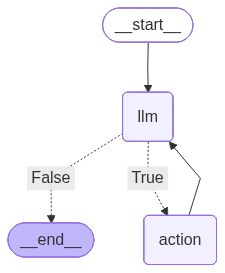

In [12]:
from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Error al tratar generar el PNG de Mermaid: {e}")
    print("\nVerifique que la versión de LangGraph posee el método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obtener la string y visualizarla externamente.")

In [14]:
from langchain_core.messages import HumanMessage

# 1. Configuración del Prompt y el Modelo (Groq)
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. 
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). 
Busca información únicamente cuando tengas claro lo que deseas. 
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!"""

model_instance = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
tool_instance = TavilySearchResults(max_results=4)

# 2. Inicialización del Agente
abot = Agent(model_instance, [tool_instance], system=prompt)

# 3. Preparación del mensaje
messages = [HumanMessage(content="Cómo está el clima en Las Altas Cumbres, Provincia de Cordoba Argentina hoy?")]

print("Iniciando la interacción con el agente:\n")
final_result_state = None

# 4. Ejecución del Stream en el Grafo
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")

# 5. Extracción segura del último mensaje del estado del nodo
if final_result_state:
    # Obtenemos el nombre del último nodo ejecutado (llm, action, etc.)
    ultimo_nodo = list(final_result_state.keys())[0]
    # Extraemos los mensajes devueltos por ese nodo
    nodo_data = final_result_state[ultimo_nodo]
    
    if 'messages' in nodo_data and nodo_data['messages']:
        print(nodo_data['messages'][-1].content)
    else:
        print("El último nodo no devolvió mensajes estructurados.")
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:

--- LLAMANDO AL MODELO (GROQ) ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3gv23wrp1', 'function': {'arguments': '{"query":"clima en Las Altas Cumbres, Provincia de Cordoba Argentina hoy"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 386, 'total_tokens': 420, 'completion_time': 0.061295636, 'completion_tokens_details': None, 'prompt_time': 0.027841266, 'prompt_tokens_details': None, 'queue_time': 0.152611248, 'total_time': 0.089136902}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eccad-a269-7023-bc37-c0baddd7e13c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Las Altas Cumbres, Provincia de Cordoba Argentina hoy'}, 'id

In [18]:
import os
from datetime import date
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
#from langchain_tavily import TavilySearchResults
#from langchain_tavily.tools import TavilySearchResults
from langchain_community.tools.tavily_search import TavilySearchResults


# 1. Obtener la fecha actual con el formato deseado
current_date = date.today().strftime("%d/%m/%Y") 

# 2. Configurar el prompt dinámico con la fecha inyectada (Corregido 'when' por 'cuando')
prompt = f"""Eres un asistente de investigación inteligente y altamente actualizado. 
Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. 
La fecha actual es {current_date}. 
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", DEBES **incluir la fecha actual '{current_date}' en tu consulta para la herramienta de búsqueda**. 
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". 
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". 
Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. 
Tienes permiso para realizar múltiples llamadas (ya sea en conjunto o en secuencia). 
Busca información solo cuando tengas claro lo que deseas. 
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!"""

# 3. Inicializar el modelo con Groq y la herramienta de búsqueda
model_instance = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
tool_instance = TavilySearchResults(max_results=4)

# 4. Crear la instancia de tu Agente
abot = Agent(model_instance, [tool_instance], system=prompt)

# 5. Preparar la consulta
user_query = "Cómo está el clima en Las Altas Cumbres, Provincia de Cordoba Argentina hoy?"
messages = [HumanMessage(content=user_query)]

print("Iniciando la interacción con el agente:\n")
final_result_state = None

# 6. Ejecutar el stream del grafo
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")

# 7. Extracción segura del contenido del último nodo ejecutado
if final_result_state:
    ultimo_nodo = list(final_result_state.keys())[0]
    nodo_data = final_result_state[ultimo_nodo]
    
    if 'messages' in nodo_data and nodo_data['messages']:
        print(nodo_data['messages'][-1].content)
    else:
        print("El último nodo no devolvió mensajes estructurados.")
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:

--- LLAMANDO AL MODELO (GROQ) ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '02qrz7f9f', 'function': {'arguments': '{"query":"clima en Las Altas Cumbres, Provincia de Cordoba, Argentina 15/06/2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 566, 'total_tokens': 607, 'completion_time': 0.087492521, 'completion_tokens_details': None, 'prompt_time': 0.038465223, 'prompt_tokens_details': None, 'queue_time': 0.242676041, 'total_time': 0.125957744}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eccbb-9638-7032-9a5b-514bc59d3a03-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Las Altas Cumbres, Provincia de Cordoba, Argentina 1

In [20]:
user_query_tomorrow = "Cómo está el clima en Las Altas Cumbres, Provincia de Cordoba Argentina mañana?" 
messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando la interacción con el agente para mañana---")
final_result_state_tomorrow = None

# Ejecución del flujo en streaming
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para mañana ---")

# Extracción segura y dinámica del contenido del último nodo ejecutado
if final_result_state_tomorrow:
    ultimo_nodo = list(final_result_state_tomorrow.keys())[0]
    nodo_data = final_result_state_tomorrow[ultimo_nodo]
    
    if 'messages' in nodo_data and nodo_data['messages']:
        print(nodo_data['messages'][-1].content)
    else:
        print("El último nodo no devolvió mensajes estructurados.")
else:
    print("Ningún resultado final o resultado inesperado para mañana.")


--- Iniciando la interacción con el agente para mañana---
--- LLAMANDO AL MODELO (GROQ) ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bjdnske66', 'function': {'arguments': '{"query":"clima en Las Altas Cumbres, Provincia de Cordoba Argentina 16/06/2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 566, 'total_tokens': 606, 'completion_time': 0.104050006, 'completion_tokens_details': None, 'prompt_time': 0.03729806, 'prompt_tokens_details': None, 'queue_time': 0.192019917, 'total_time': 0.141348066}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eccc3-4394-7921-861e-69d16152c4e9-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Las Altas Cumbres, Provincia de Cord

In [21]:
from langchain_core.messages import HumanMessage

user_query_yesterday = "Cómo fue el clima en Las Altas Cumbres, Provincia de Cordoba Argentina ayer?" 
messages_yesterday = [HumanMessage(content=user_query_yesterday)]

print("\n--- Iniciando la interacción con el agente ---")
final_result_state_yesterday = None

# Ejecución del flujo en streaming
for s in abot.graph.stream({"messages": messages_yesterday}):
    print(s)
    print("---")
    final_result_state_yesterday = s

print("\n--- Resultado Final ---")

# Extracción segura y dinámica del contenido del último nodo ejecutado
if final_result_state_yesterday:
    ultimo_nodo = list(final_result_state_yesterday.keys())[0]
    nodo_data = final_result_state_yesterday[ultimo_nodo]
    
    if 'messages' in nodo_data and nodo_data['messages']:
        print(nodo_data['messages'][-1].content)
    else:
        print("El último nodo no devolvió mensajes estructurados.")
else:
    print("Ningún resultado final o resultado inesperado.")


--- Iniciando la interacción con el agente ---
--- LLAMANDO AL MODELO (GROQ) ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xb7eqk63n', 'function': {'arguments': '{"query":"clima en Las Altas Cumbres, Provincia de Cordoba, Argentina 14/06/2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 567, 'total_tokens': 608, 'completion_time': 0.088127312, 'completion_tokens_details': None, 'prompt_time': 0.163307959, 'prompt_tokens_details': None, 'queue_time': 0.194163519, 'total_time': 0.251435271}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eccc8-2b64-7cc2-b1bc-fb8b57cb96b2-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Las Altas Cumbres, Provincia de Cordoba, Arge

In [22]:
# 1. Definir los mensajes de entrada
messages = [HumanMessage(content="Cómo está el clima en Las Altas Cumbres, Provincia de Cordoba Argentina hoy?")]

# 2. Invocar el grafo (ejecución síncrona completa)
result = abot.graph.invoke({"messages": messages})

# 3. Mostrar la respuesta final del agente de forma limpia
print("Respuesta del Agente:")
if 'messages' in result and result['messages']:
    print(result['messages'][-1].content)
else:
    print("No se encontró una respuesta estructurada en el estado del grafo.")

--- LLAMANDO AL MODELO (GROQ) ---
Llamado a la herramienta: tavily_search_results_json
Volviendo al modelo!
--- LLAMANDO AL MODELO (GROQ) ---
Respuesta del Agente:
El clima en Las Altas Cumbres, Provincia de Cordoba, Argentina hoy es de neblina, con temperaturas de 12° / 4° y viento moderado de noroeste.


In [23]:
result['messages'][-1].content

'El clima en Las Altas Cumbres, Provincia de Cordoba, Argentina hoy es de neblina, con temperaturas de 12° / 4° y viento moderado de noroeste.'

In [24]:
# 1. Definir los mensajes de entrada con la consulta de múltiples ciudades
messages = [HumanMessage(content="Cómo está el clima en Las Altas Cumbres, Provincia de Cordoba Argentina y en Kansas City USA hoy?")]

# 2. Invocar el grafo de forma síncrona
result = abot.graph.invoke({"messages": messages})

# 3. Mostrar la respuesta final consolidada
print("Respuesta del Agente:")
if 'messages' in result and result['messages']:
    print(result['messages'][-1].content)
else:
    print("No se encontró una respuesta estructurada en el estado final.")

--- LLAMANDO AL MODELO (GROQ) ---
Llamado a la herramienta: tavily_search_results_json
Llamado a la herramienta: tavily_search_results_json
Volviendo al modelo!
--- LLAMANDO AL MODELO (GROQ) ---
Respuesta del Agente:
El clima en Las Altas Cumbres, Provincia de Cordoba, Argentina el 15 de junio de 2026 es de 12° con neblina, mientras que en Kansas City, USA, el clima es de 25° con posibilidad de lluvia.


In [25]:
result['messages'][-1].content

'El clima en Las Altas Cumbres, Provincia de Cordoba, Argentina el 15 de junio de 2026 es de 12° con neblina, mientras que en Kansas City, USA, el clima es de 25° con posibilidad de lluvia.'

In [26]:
from langchain_core.messages import HumanMessage

# 1. Definir la consulta compleja sobre el pasado
query_pasado = """¿Qué país fue sede de la Copa Mundial de fútbol en 1978? ¿Quién fue el campeón y cuál fue el marcador de la final?
¿Cuál era el Producto Interno Bruto (PIB) de ese país en el año de la Copa y cuál es el PIB actual (últimos datos disponibles)?
¿Cuál es la capital de ese país y cuál es su moneda actual? Responda a cada pregunta por separado."""

messages = [HumanMessage(content=query_pasado)]

print("\nIniciando la interacción con el agente para pregunta sobre el pasado:\n")
final_result_state = None

# 2. Ejecutar el stream del grafo
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    # Guardamos el último estado emitido directamente
    final_result_state = s

print("\n--- Resultado Final para el Pasado ---")

# 3. Extracción segura y dinámica del contenido del último nodo ejecutado
if final_result_state:
    ultimo_nodo = list(final_result_state.keys())[0]
    nodo_data = final_result_state[ultimo_nodo]
    
    if 'messages' in nodo_data and nodo_data['messages']:
        print(nodo_data['messages'][-1].content)
    else:
        print("El último nodo no devolvió mensajes estructurados.")
else:
    print("Ningún resultado final o resultado inesperado.")


Iniciando la interacción con el agente para pregunta sobre el pasado:

--- LLAMANDO AL MODELO (GROQ) ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a37cg3rss', 'function': {'arguments': '{"query":"país sede de la Copa Mundial de fútbol en 1978"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '07wd3bem1', 'function': {'arguments': '{"query":"campeón y marcador de la final de la Copa Mundial de fútbol en 1978"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'vdv2cysrs', 'function': {'arguments': '{"query":"PIB de Argentina en 1978 y PIB actual"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '2jkgc94m6', 'function': {'arguments': '{"query":"capital de Argentina"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'rjtccs1nb', 'function': {'arguments': '{"query":"moneda actual de Argentina"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response

In [27]:
print("\n--- Agente de Búsqueda Interactivo ---")
print("Digite su pregunta o 'salir' para finalizar la conversación.")

while True:
    user_input = input("\nUsted: ") 
    if user_input.lower() == "salir":
        print("Agente: Finalizando la conversación. Hasta luego!")
        break

    # Asegurarnos de que el usuario no envíe un espacio en blanco
    if not user_input.strip():
        continue

    messages = [HumanMessage(content=user_input)]
    print("Agente: Pensando y buscando...")
    
    final_result_state = None
    try:
        # Ejecutar el stream guardando siempre el último paso emitido
        for s in abot.graph.stream({"messages": messages}):
            final_result_state = s

        print("\nAgente:")

        # Extracción segura y dinámica de la respuesta final
        if final_result_state:
            ultimo_nodo = list(final_result_state.keys())[0]
            nodo_data = final_result_state[ultimo_nodo]
            
            if 'messages' in nodo_data and nodo_data['messages']:
                final_message = nodo_data['messages'][-1]
                print(final_message.content)
            else:
                print("El último nodo no devolvió mensajes estructurados.")
        else:
            print("No fue posible obtener una respuesta del agente para esta pregunta.")

    except Exception as e:
        print(f"Agente: Se presentó un error durante la ejecución: {e}")
        print("Intente nuevamente, o digite 'salir'.")

print("\n--- Conversación finalizada ---")


--- Agente de Búsqueda Interactivo ---
Digite su pregunta o 'salir' para finalizar la conversación.
Agente: Pensando y buscando...
--- LLAMANDO AL MODELO (GROQ) ---
Llamado a la herramienta: tavily_search_results_json
Volviendo al modelo!
--- LLAMANDO AL MODELO (GROQ) ---

Agente:
El favorito en el partido entre Uruguay y Arabia Saudita es Uruguay, según las cuotas y la calidad de su plantilla dirigida por Marcelo Bielsa.
Agente: Finalizando la conversación. Hasta luego!

--- Conversación finalizada ---
